## 10. Generating filament images with eROSITA

The following notebook works on developing the code for generation of filament images with the eRASS:4 survey! :D The aim of the class must be as follows:
1. Take the ra, dec of the filament spine 
2. Go to the appropriate erass directory and find the skytile(s) that the filament belongs to
3. Generate the images in differnet energy bands

**Author**: Soumya Shreeram <br/>
**Contact email**: shreeram@mpe.mpg.de <br/>
**Date created**: 28th September 2022 <br/>
**Date last editted**: 26th October 2022

In [2]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits
from astropy.table import Table, Column, QTable
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18, z_at_value

from astrotools import healpytools as hpt
from gdpyc import GasMap
    
import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import copy

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib import cm
import seaborn as sns

import healpy as hp
from healpy.newvisufunc import projview, newprojplot

In [3]:
import filaments as fo

In [4]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
mpl.rc('font', **font)

bright_colors = sns.color_palette("bright")

In [5]:
%load_ext autoreload
%autoreload 2

In [5]:
example_file = '/data53s/mpecl_erass1/data_s4/194084/c020/sm04_194084_020_EventList_c020.fits'

In [6]:
example_table = Table.read(example_file)
example_table[0]

TIME,RA,DEC,X,Y,PI,EV_WEIGHT,RAWX,RAWY,SUBX,SUBY,PHA,PAT_TYP,PAT_INF,TM_NR,FLAG,FRAMETIME,RECORDTIME
s,deg,deg,,,,,,,,,,,,,,s,
float64,float64,float64,float64,float64,float32,float32,int16,int16,float64,float64,int16,int16,uint8,uint8,int32,float64,float64
629889712.304087,191.77022705056694,8.580154585336023,123131.0,185829.0,733.92523,0.0,77,215,-0.32999999941,-0.2699999993800001,880,1,5,2,117440514,629889712.304087,629889712.36


In [6]:
this_file = fo.DisPerSEcatalog2eRass(data_set='lc_north_dis',
                                    smoothing_density_f='SD2',
                                    persistence=5,
                                    smoothing_skeleton='S001')

t = Table.read(f'{this_file.reformatted_filename}.fit')

INFO:DisPerSEcatalog2eRass:<DisPerSEcatalog2eRass(data_set=lc_north_dis, smoothing_density_f=SD2, persistence=5, smoothing_skeleton=S001, section=fil)>
INFO:DisPerSEcatalog2eRass:total filaments available 351
INFO:DisPerSEcatalog2eRass:===========

INFO:DisPerSEcatalog2eRass:German half of the sky has:
INFO:DisPerSEcatalog2eRass:Total 220
INFO:DisPerSEcatalog2eRass:Length and orientation cut 11
INFO:DisPerSEcatalog2eRass:Only length cut 18
INFO:DisPerSEcatalog2eRass:Only orientation cut 134
INFO:DisPerSEcatalog2eRass:===========

INFO:DisPerSEcatalog2eRass:Russian half of the sky has:
INFO:DisPerSEcatalog2eRass:Total 131
INFO:DisPerSEcatalog2eRass:Length and orientation cut 21
INFO:DisPerSEcatalog2eRass:Only length cut 28
INFO:DisPerSEcatalog2eRass:Only orientation cut 101
INFO:DisPerSEcatalog2eRass:===========



In [9]:
t[96]['Sky_tile_no'].split(', ')

['220105',
 '209096',
 '236096',
 '218096',
 '221096',
 '224096',
 '230096',
 '233096',
 '224087',
 '221102',
 '221087',
 '218087',
 '215087',
 '224090',
 '212102',
 '215102',
 '215096',
 '212096',
 '209090',
 '212090',
 '233093',
 '230093',
 '227093',
 '224093',
 '221093',
 '218093',
 '215093',
 '212093',
 '209093',
 '215090',
 '218090',
 '221090',
 '230090',
 '218102',
 '212087',
 '224102',
 '224084',
 '218084',
 '227102',
 '214105',
 '217105',
 '223105',
 '226105',
 '229105',
 '215084',
 '212084',
 '209084',
 '206084',
 '219081',
 '216081',
 '213081',
 '210081',
 '221084',
 '227090',
 '209087',
 '227087',
 '211105',
 '225099',
 '214075',
 '213099',
 '206096',
 '210099',
 '222099',
 '208105',
 '209102',
 '232105',
 '231099',
 '234099',
 '211075',
 '216099',
 '219099',
 '207081',
 '205105',
 '228099',
 '235105',
 '230102',
 '227096',
 '206102',
 '203102',
 '203084',
 '233102',
 '207099',
 '204081',
 '203096',
 '204099',
 '206087',
 '208075',
 '202105',
 '203087',
 '206093',
 '206090',

In [47]:
this_file.add_skytile_info()

INFO:DisPerSEcatalog2eRass:Size croping around the filament 6.84
INFO:DisPerSEcatalog2eRass:Adding new column with sky tile no and percentage, len(355). Table has length: 355
INFO:DisPerSEcatalog2eRass: Modified saved table


How many of the selected entries do not have a skytile counterpart in the sky? Seems like more than majority of the sample returns no skytile

In [8]:
valid_entries = (t['Sky_tile_no' ] != 'None')

# number of entries that are no in the german sky after the length and orientation cut
print('These are to total number of filaments ', len(t[valid_entries]['Sky_tile_no']))

# number of entries that are supposed to be in the german sky, but return empty strings for skytile search
true_outputs = (t[valid_entries]['Sky_tile_no' ] != '')
print('Number of filaments found in the German sky ', len(t[valid_entries][true_outputs]))
print('First estimate made by me using a simple latitude cut ', len(t[t['Ownership'] == 'DE']))
percent_lost = 1 - len(t[valid_entries][true_outputs])/len(t[t['Ownership'] == 'DE'])
print(f"the ones that return no sky tile {percent_lost*100:.2f} %")

These are to total number of filaments  10067
Number of filaments found in the German sky  10067
First estimate made by me using a simple latitude cut  45025
the ones that return no sky tile 77.64 %


In [9]:
valid_entries = (t['Sky_tile_no' ] != '') & (t['Sky_tile_no' ] != 'None')

selection_cuts = np.where(valid_entries & 
                          this_file.select_lengths & 
                          this_file.orientation_cut          
                         )[0]
z_selected, fil_ids_selected = np.array([]), np.array([])
skytiles_selected = []
for i in range(len(t[selection_cuts])):
    fil_id = selection_cuts[i]
    fil_ids_selected = np.append(fil_ids_selected, fil_id)
    
    z_selected = np.append(z_selected, t[fil_id]['median_redshift'])
    skytiles_selected.append(t[fil_id]['Sky_tile_no'])

Trying to test the code developed on higher redshift filaments as they will generate lower images sizes

In [74]:
finer_selection = np.where(z_selected>0.1)
print(fil_ids_selected[finer_selection])
print(np.array(skytiles_selected)[finer_selection])

[156. 157. 159. 166. 186. 217. 223. 295. 299. 302. 305. 319. 344. 351.]
['221090, 218090, 221093, 218093, 221087, 218087, 224090, 215090, 224093, 215093, 224087, 215087'
 '224090, 224087, 221090, 221087, 227090, 227087, 224093, 221093, 224084, 227093, 221084'
 '233093'
 '123081, 119081, 121078, 124078, 122084, 126081, 125084, 119084, 117078, 127078, 116081'
 '125084, 125087, 122084, 128084, 128087, 122087, 126081, 123081, 125090, 129081, 128090, 122090, 119081'
 '112051, 108051, 116051, 117048, 111054, 115054, 107054, 118054'
 '112051, 116051, 117048, 108051, 115054, 111054, 119051, 118054, 107054'
 '230090, 233093, 230093, 227090, 227093, 233096, 230096, 227087, 227096, 236096'
 '239096, 236096'
 '230093, 227093, 230090, 227090, 233093, 230096, 227096, 227087, 224093, 224090, 233096, 224096, 224087'
 '227090, 224090, 227093, 224093, 227087, 224087, 221090, 221093, 230090, 230093, 227096, 224096, 221087, 221096, 230096'
 '233093, 230090, 230093'
 '140087, 137087, 140084, 137084, 140090

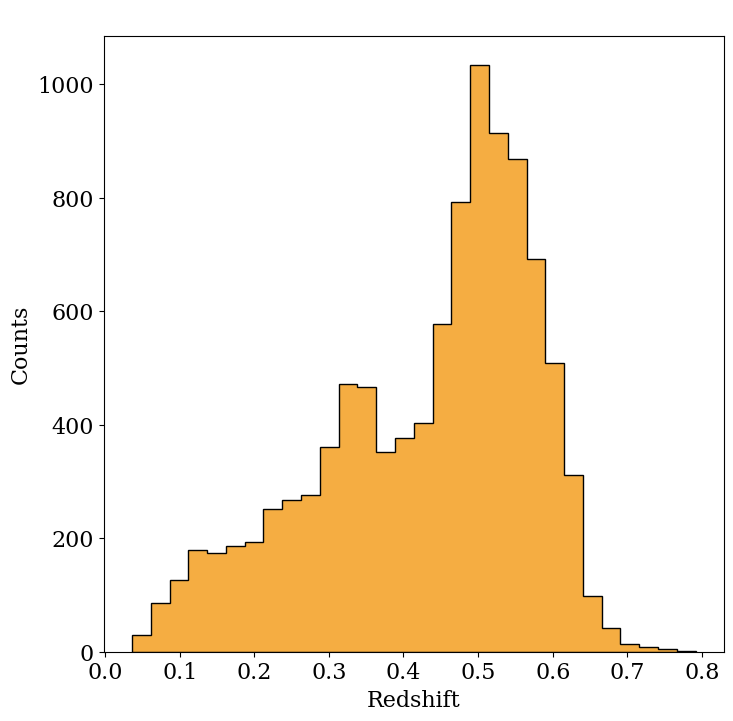

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.hist(z_selected, bins=30, histtype='stepfilled', color='#f5ad42', edgecolor='k')
#fo.set_as_white(ax)
fo.set_labels(ax, 'Redshift', 'Counts', 'Selected filaments redshift distribution')
#fig.savefig(f"{this_file.base_dir}/images/{this_file.directory_name}_{this_file.filament_name}.png",format="png", facecolor='k')

In [ ]:
this_file.create_eventfile_list()

The following code block is to test a particular case of 

In [5]:
this_file.get_data_products(fil_id=156, 
                            skytiles=[221090, 218090, 221093, 218093, 221087, 218087, 224090, 215090, 224093, 215093, 224087, 215087],
                           clean_eventfile=False, clobber=False,
                           make_images=False)

INFO:DisPerSEcatalog2eRass:'proc_v_folder' default set to c020
INFO:DisPerSEcatalog2eRass:'pattern' not set; setting it to the default value of '15'
INFO:DisPerSEcatalog2eRass:'bandEs' not set; setting it to the default value of '((200, 2300), (200, 600), (600, 1100), (1100, 1600), (1600, 2200), (2200, 3500), (3500, 5000), (5000, 7000))'. \
                Remember that units are eV. Also note that you can also pass tuples,\
                e.g. bandEs=( (200, 600), (600, 1100), (1100, 1600), (1600,2200),\
                (2200, 3500), (3500, 5000), (5000, 7000))
INFO:DisPerSEcatalog2eRass:'rcrop' set to  2.52 degrees
INFO:DisPerSEcatalog2eRass: box sides are 2.52 degree, image has 283 pixels


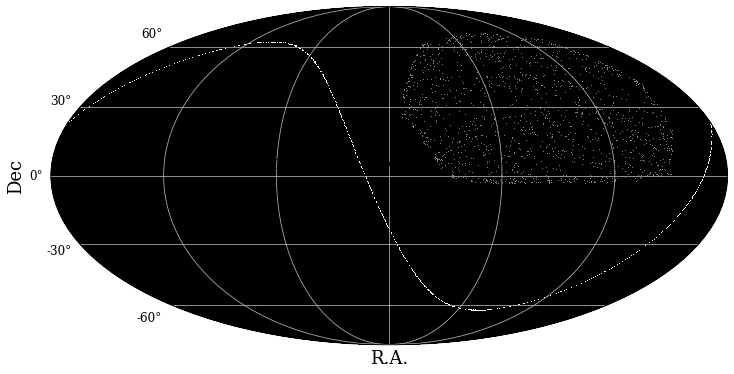

In [203]:
milky_way_map = fo.get_milky_way()
fil_median_map = fo.produce_healpy_map(256, t['median_ra'] + this_file.ra_c, t['median_dec'] + this_file.dec_c)

# plot healpy map
fo.healpy_mollview(fil_median_map+milky_way_map, vmax=1.1, 
                       rot=[270, 0])
    

Checking if all the skytiles in the skymaps file are also in the eRASS:4 directory

In [204]:
filename = os.path.join(this_file.save_data_dir, "SKYMAPS_052022.fits")
skymap = fits.open(filename)
allsky = skymap['SMAPS'].data
de_sky = allsky[allsky['OWNER'] != 1]         

In [205]:
tile_nr = de_sky['SRVMAP']

In [216]:
tiles_actually_in_directory = glob.glob(f"{this_file.eRASS4_dir}/*")

In [219]:
for i, tiles in enumerate(tiles_actually_in_directory):
    tiles_actually_in_directory[i] = int(tiles[-6:])

In [222]:
len(tiles_actually_in_directory)

2447

In [223]:
len(tile_nr)

2447

In [224]:
np.all(np.sort(tile_nr) == np.sort(tiles_actually_in_directory))

True

So yes, all the skytiles in the file are also in the erass:4 directory

### Generation of masks

In [6]:
image_names_path = f"{this_file.inputs_folder}/all_filament_image_names.txt"

In [ ]:
this_file.mask_clusters_point_srcs()

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
Set MJD-OBS to 58860.096076 from DATE-OBS.
Set MJD-END to 59430.214120 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58860.096076 from DATE-OBS.
Set MJD-END to 59430.214120 from DATE-END'.


In [7]:
np.loadtxt(image_names_path)

/home/shreeram/miniconda3/envs/eroconda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: loadtxt: Empty input file: "/data53s/shreeram/Filament_stacking/data/Stacking_filaments/eRass_products/legacy_north_dis_SD2_s5.0_S001/filid156_len_63.93Mpc_12pts_5.50deg/inputs/all_filament_image_names.txt"
  """Entry point for launching an IPython kernel.


array([], dtype=float64)